Training an FNN neural network with scaled dataframe

In [8]:
!pip install keras
!pip install tensorflow
!pip install scikeras

Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None


In [9]:
#Importing modules and librarie
import tensorflow.keras as keras
import pandas as pd
import numpy as np
from scikeras.wrappers import KerasClassifier

In [10]:
#Loading dataframe 
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Typing dataset/nn.csv")


In [11]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons
0,-0.886935,-1.215000,-1.130382,1.187889,1.261341,True
1,-0.886935,1.934492,-1.130382,-0.457969,0.757723,True
2,1.127478,-0.749734,1.312729,0.434741,0.657000,False
3,-0.886935,-1.215000,-1.130382,-0.316002,-0.352818,True
4,-0.886935,1.117295,0.498359,-1.632207,-1.360053,False
...,...,...,...,...,...,...
742400,1.127478,0.652029,1.312729,1.750946,1.868264,True
742401,-0.886935,-0.278503,0.498359,-0.503687,-0.554265,True
742402,1.127478,-1.215000,1.312729,0.622426,1.059894,False
742403,1.127478,0.652029,-0.316012,1.375575,1.462788,True


In [12]:
#Dropping the hand and direction columns since they might not be predictive
df = df.drop(columns = ["Hand", "Direction"])

In [13]:
df["Parkinsons"].isna().sum()

0

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
df["Parkinsons"].isna().sum()

0

In [16]:
df["Parkinsons"].value_counts()

Parkinsons
False    427655
True     314750
Name: count, dtype: int64

In [17]:
#Dividing into train_test_split and defining labels
df["Parkinsons"] = df["Parkinsons"].astype(int)

print(df["Parkinsons"].value_counts())

y = df["Parkinsons"]

X = df.drop(columns=["Parkinsons"])

from imblearn.over_sampling import SMOTE
from collections import Counter

# Assume X and y are your features and labels
print("Original class distribution:", Counter(y))

rus = SMOTE(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled class distribution:", Counter(y_resampled))

X_train, X_test, y_train , y_test = train_test_split(X_resampled, y_resampled, random_state=42, test_size=0.2)


Parkinsons
0    427655
1    314750
Name: count, dtype: int64
Original class distribution: Counter({0: 427655, 1: 314750})


/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled class distribution: Counter({1: 427655, 0: 427655})


In [18]:
#Making sure my featurs are int or floats
print(X_train.dtypes)

HoldTime       float64
LatencyTime    float64
FlightTime     float64
dtype: object


In [19]:
print(y)

0         1
1         1
2         0
3         1
4         0
         ..
742400    1
742401    1
742402    0
742403    1
742404    0
Name: Parkinsons, Length: 742405, dtype: int64


In [20]:
#Defining the loss function  and optimizer
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

optim = keras.optimizers.Adam(learning_rate=0.001)


2025-08-05 20:02:00.535019: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [21]:
#Creating the NN Architecture 


nn_model = keras.Sequential()

#Input layer 
input_layer = keras.layers.InputLayer(input_shape = (len(X_train.columns),))
nn_model.add(input_layer)

#Hidden layer 1
hidden_layer_1 = keras.layers.Dense(units = 128, activation="relu")
nn_model.add(hidden_layer_1)

#Hidden layer 2
hidden_layer_2 = keras.layers.Dense(units=64, activation="relu")
nn_model.add(hidden_layer_2)

#hidden layer 3
hidden_layer_3 = keras.layers.Dense(units=32, activation="relu")
nn_model.add(hidden_layer_3)
dropout = keras.layers.Dropout(0.2)
nn_model.add(dropout)

#extra hidden layer 
hidden_layer_5 = keras.layers.Dense(units=16, activation="relu")
nn_model.add(hidden_layer_5)
nn_model.add(keras.layers.Dropout(0.2))

#hidden layer 4 / output 5
hidden_layer_4 = keras.layers.Dense(units=1, activation="sigmoid")
nn_model.add(hidden_layer_4)


 #Compiling the model
nn_model.compile(optimizer=optim, loss=loss_fn, metrics=["accuracy"])



/users/imbahndu/.local/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [22]:
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Fitting the model
num_epochs = 50
model = nn_model.fit(X_train, y_train, epochs=num_epochs, validation_split=0.3)

Epoch 1/50
14968/14968 ━━━━━━━━━━━━━━━━━━━━ 150s 9ms/step - accuracy: 0.5852 - loss: 0.6731 - val_accuracy: 0.5936 - val_loss: 0.6653
Epoch 2/50
14968/14968 ━━━━━━━━━━━━━━━━━━━━ 205s 10ms/step - accuracy: 0.5920 - loss: 0.6682 - val_accuracy: 0.5963 - val_loss: 0.6643
Epoch 3/50
14968/14968 ━━━━━━━━━━━━━━━━━━━━ 225s 11ms/step - accuracy: 0.5942 - loss: 0.6669 - val_accuracy: 0.5967 - val_loss: 0.6638
Epoch 4/50
14968/14968 ━━━━━━━━━━━━━━━━━━━━ 185s 10ms/step - accuracy: 0.5940 - loss: 0.6663 - val_accuracy: 0.5967 - val_loss: 0.6639
Epoch 5/50
14968/14968 ━━━━━━━━━━━━━━━━━━━━ 155s 7ms/step - accuracy: 0.5952 - loss: 0.6658 - val_accuracy: 0.5970 - val_loss: 0.6636
Epoch 6/50


In [ ]:
#Evaluating the model's accuracy and loss over time through visualizations
print(model.history.keys())
import matplotlib.pyplot as plt

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


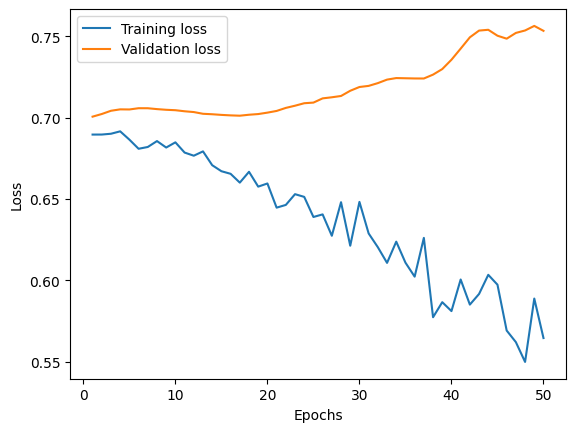

In [ ]:
#Plotting loss 
plt.plot(range(1, num_epochs+1), model.history['loss'], label="Training loss")
plt.plot(range(1, num_epochs+1), model.history['val_loss'], label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

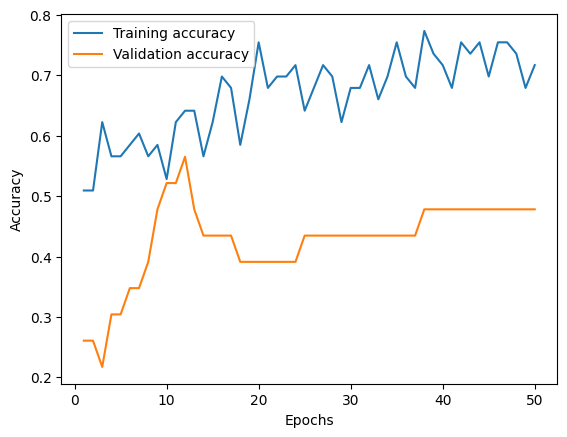

In [ ]:
plt.plot(range(1, num_epochs+1), model.history['accuracy'], label="Training accuracy")
plt.plot(range(1, num_epochs+1), model.history['val_accuracy'], label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
loss, accuracy = nn_model.evaluate(X_test,y_test)
print("Loss is ", loss)
print("Accuracy is", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3500 - loss: 0.9363
Loss is  0.9362673759460449
Accuracy is 0.3499999940395355


In [ ]:
#Predictions on X_test and setting threshold to 
predict_label = nn_model.predict(X_test)
predict_label_int = (predict_label >= 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


In [ ]:
#Confusion matrix and classification report 

print(confusion_matrix(y_test, predict_label_int))

print(classification_report(y_test, predict_label_int))

print(accuracy_score(y_test, predict_label_int))

[[3 6]
 [7 4]]
              precision    recall  f1-score   support

           0       0.30      0.33      0.32         9
           1       0.40      0.36      0.38        11

    accuracy                           0.35        20
   macro avg       0.35      0.35      0.35        20
weighted avg       0.35      0.35      0.35        20

0.35


/tmp/ipykernel_2053726/78027907.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<function matplotlib.pyplot.show(close=None, block=None)>

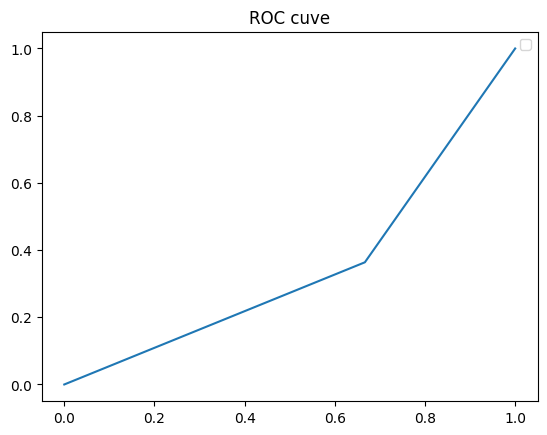

In [ ]:
from sklearn.metrics import roc_curve
import seaborn as sns

fpr, tpr, threshold = roc_curve(y_test, predict_label_int)
sns.lineplot(x=fpr, y=tpr)
plt.title("ROC cuve")
plt.legend()
plt.show